# Análise Comparativa de Modelos

**Projeto:** Projeto ANEEL - Energia em Risco: Análise de Dados de Continuidade Elétrica e Previsão de Risco Regulatório

**Metodologia:** CRISP-DM

**Período de Análise:** 2021 – 2025

---

## Visão Geral

Este notebook faz parte da **Fase 4 do CRISP-DM - Modelagem (Modeling)** com o consumo da base preparada, a definição das métricas, o modelo de baseline e os modelos candidatos.

---

## Sumário

1. Configurações do ambiente  
2. Objetivo da modelagem  
3. Carregamento da base preparada  
4. Baseline e estratégia de avaliação  
5. Modelos candidatos  
---

## 1. Configurações do ambiente

Esta etapa mantém o padrão de configuração utilizado nos notebooks anteriores: ambiente `.venv`, caminhos derivados de `PROJECT_ROOT`, opções de visualização e `RANDOM_STATE` fixo para permitir a reprodução dos experimentos.

In [88]:
# Importações e configurações do ambiente
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.data.constants import ANO_INICIO, ANO_FIM

MODEL_DATA_DIR = PROCESSED_DIR / "modeling"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

os.makedirs(MODEL_DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")
sns.set_theme(style="whitegrid")

print(f"Período analisado: {ANO_INICIO}-{ANO_FIM}")
print(f"RANDOM_STATE: {RANDOM_STATE}")

Período analisado: 2021-2025
RANDOM_STATE: 42


In [89]:
# Definindo a paleta de cores
colors = ["#959300", "#01719f", "#004e72"]
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette(colors))

custom_cmap = LinearSegmentedColormap.from_list("custom_colors", colors[::-1])

custom_cmap.set_under(colors[::-1][0])
custom_cmap.set_bad(colors[::-1][0])

---

## 2. Objetivo da modelagem

O objetivo é comparar modelos de classificação capazes de prever o `alvo`, isto é, a ocorrência de transgressão regulatória no período seguinte para cada conjunto e indicador.

1. **Entradas esperadas do notebook 04:** `X_train`, `y_train`, `X_validation`, `y_validation`, `X_test` e `y_test`.

2. **Partições:** Treino `(2021–2023)`, validação `(2024)` e teste `(2025)`. A ordem temporal deve ser preservada em todas as avaliações.

3. **Modelo Baseline:** Classificador simples e interpretável, utilizado como referência mínima.

4. **Modelos Candidatos:** Modelos lineares e baseados em boosting, treinados com tratamento do desbalanceamento definido no notebook 04.

5. **Métricas Prioritárias:** `Precision`, `Recall`, `F1-score`, `PR-AUC` e `Matriz de Confusão`. A acurácia não será usada como critério principal devido à raridade das transgressões.

6. **Critério de Seleção:** Escolher o modelo que ofereça melhor equilíbrio entre detecção das transgressões, precisão dos alertas, estabilidade temporal e interpretabilidade operacional.

---

## 3. Carregamento da base preparada

As matrizes são carregadas a partir dos Parquets exportados pelo notebook 04. O carregamento valida a existência das seis entradas esperadas, o alinhamento das colunas e a ausência de nulos nos atributos.

In [90]:
# Carregamento e validação das matrizes exportadas pelo notebook 04

required_model_files = [
    MODEL_DATA_DIR / "X_train.parquet",
    MODEL_DATA_DIR / "X_validation.parquet",
    MODEL_DATA_DIR / "X_test.parquet",
    MODEL_DATA_DIR / "y_train.parquet",
    MODEL_DATA_DIR / "y_validation.parquet",
    MODEL_DATA_DIR / "y_test.parquet",
    MODEL_DATA_DIR / "modeling_metadata.json",
]
missing_model_files = [str(path) for path in required_model_files if not path.exists()]
if missing_model_files:
    raise FileNotFoundError(
        "Matrizes ou metadados ausentes. Execute a exportação no notebook 04:\n"
        + "\n".join(missing_model_files)
    )

X_train = pd.read_parquet(required_model_files[0])
X_validation = pd.read_parquet(required_model_files[1])
X_test = pd.read_parquet(required_model_files[2])
y_train = pd.read_parquet(required_model_files[3])["alvo"]
y_validation = pd.read_parquet(required_model_files[4])["alvo"]
y_test = pd.read_parquet(required_model_files[5])["alvo"]
modeling_metadata = pd.read_json(required_model_files[6]).iloc[0].to_dict()
scale_pos_weight = float(modeling_metadata["scale_pos_weight"])

assert list(X_train.columns) == list(X_validation.columns) == list(X_test.columns)
assert int(X_train.isna().sum().sum()) == 0
assert int(X_validation.isna().sum().sum()) == 0
assert int(X_test.isna().sum().sum()) == 0
assert int(y_train.sum()) == int(modeling_metadata["train_positives"])
assert int(len(y_train) - y_train.sum()) == int(modeling_metadata["train_negatives"])

model_input_summary = pd.DataFrame(
    [
        {
            "particao": "treino",
            "observacoes": len(X_train),
            "atributos": X_train.shape[1],
            "transgressoes": int(y_train.sum()),
        },
        {
            "particao": "validacao",
            "observacoes": len(X_validation),
            "atributos": X_validation.shape[1],
            "transgressoes": int(y_validation.sum()),
        },
        {
            "particao": "teste",
            "observacoes": len(X_test),
            "atributos": X_test.shape[1],
            "transgressoes": int(y_test.sum()),
        },
    ]
)

display(model_input_summary)
print(f"scale_pos_weight carregado do notebook 04: {scale_pos_weight:.4f}")

,particao,observacoes,atributos,transgressoes
0,treino,223184,129,70
1,validacao,75072,129,14
2,teste,69026,129,6


scale_pos_weight carregado do notebook 04: 3187.3429


---

## 4. Métricas de avaliação

A avaliação combina métricas com diferentes sensibilidades ao desbalanceamento, rigor estatístico na calibração de riscos e tolerância a alarmes falsos:

1. **Precision (Precisão)**  

    - **O que mede:** A proporção de verdadeiras transgressões entre todas as instâncias que o modelo classificou como transgressão ($\frac{TP}{TP + FP}$).

    - **Por que é essencial?** Mede a eficiência operacional do modelo.

2. **Recall (Sensibilidade)**  

    - **O que mede:** A proporção de transgressões reais que foram identificadas com sucesso pelo modelo ($\frac{TP}{TP + FN}$).

    - **Por que é essencial?** É a métrica de proteção regulatória. Um recall baixo significa que violações de DEC/FEC ocorrerão sem aviso prévio, gerando multas, compensações financeiras aos consumidores e autuações da ANEEL.

3. **F1-Score**  

    - **O que mede:** A média harmônica entre Precision e Recall ($2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$), atribuindo peso idêntico a ambos.

    - **Por que é essencial?** Fornece um resumo único do equilíbrio entre alarmes falsos e transgressões não detectadas em um limiar de corte fixo ($0{,}50$).

4. **ROC-AUC**  

    - **O que mede:** A probabilidade de o classificador atribuir um score mais alto a um conjunto com transgressão sorteado aleatoriamente do que a um conjunto sem transgressão.

    - **Por que é essencial?** Serve como benchmark padrão da literatura técnica e avalia a separabilidade global das classes ao longo de múltiplos limiares de falso positivo.

5. **PR-AUC**  

    - **O que mede:** O desempenho agregado do modelo integrando todos os limiares de decisão possíveis exclusivamente sobre a classe positiva (minoritária).

    - **Por que é essencial?** É o critério principal para seleção e ranqueamento dos modelos. Em bases com forte desbalanceamento, reflete a capacidade discriminatória real sem ser mascarada pelo volume massivo de instâncias sem transgressão.

6. **Matriz de Confusão**  

    - **O que mede:** O mapeamento quantitativo absoluto das predições cruzadas com a realidade, dividido em Verdadeiros Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) e Verdadeiros Positivos (TP).
    
    - **Por que é essencial?** Permite auditar os volumes brutos de erros e acertos em cada partição temporal, possibilitando traduzir diretamente a acurácia técnica do algoritmo.

---

## 5. Baseline e estratégia de avaliação

O baseline sempre prevê a classe majoritária observada no treino. Ele não representa um modelo operacional, mas estabelece o desempenho mínimo que os modelos candidatos precisam superar.

A avaliação será feita na validação, usando as métricas adequadas ao evento raro. A matriz de confusão mostrará se o modelo consegue identificar transgressões ou apenas reproduz a classe dominante.

In [91]:
# Baseline de classe majoritária e função de avaliação
def evaluate_classifier(model_name, y_true, predictions, scores):
    return {
        "modelo": model_name,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1_score": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
    }


baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_validation)
baseline_scores = baseline_model.predict_proba(X_validation)[:, 1]

baseline_metrics = pd.DataFrame(
    [
        evaluate_classifier(
            "baseline_classe_majoritaria",
            y_validation,
            baseline_predictions,
            baseline_scores,
        )
    ]
)
baseline_confusion = confusion_matrix(y_validation, baseline_predictions)

display(baseline_metrics)

,modelo,precision,recall,f1_score,roc_auc,pr_auc
0,baseline_classe_majoritaria,0.00,0.00,0.00,0.50,0.00


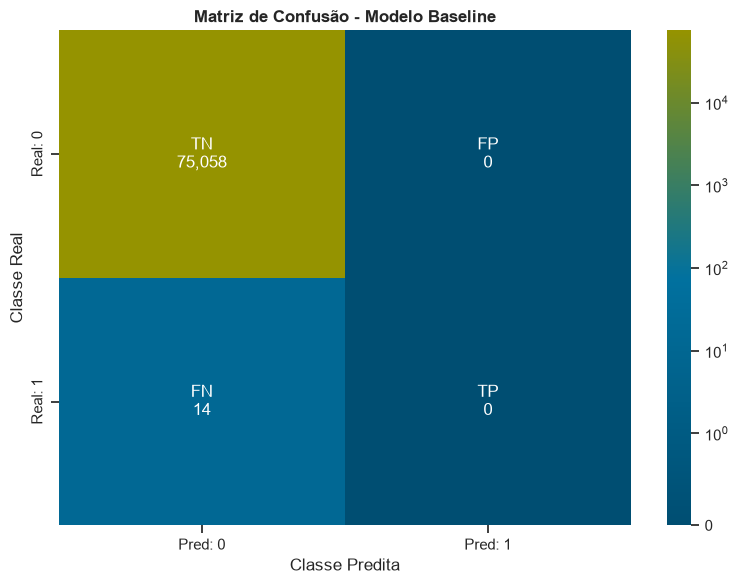

Gráfico salvo com sucesso em: ..\reports\figures\confusion_matrix_baseline_model.png


In [92]:
# Matriz de confusão do modelo baseline

full_image_path = os.path.join(FIGURES_DIR, "confusion_matrix_baseline_model.png")
relative_image_path = os.path.relpath(full_image_path)

tn, fp, fn, tp = baseline_confusion.ravel()

labels = [
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"],
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    baseline_confusion,
    annot=labels,
    fmt="",
    cmap=custom_cmap,
    norm=SymLogNorm(
        linthresh=1.0,  # Região linear entre 0 e 1 (garante cor visível para zero)
        vmin=0,
        vmax=baseline_confusion.max(),
        base=10,
    ),
    cbar=True,
    xticklabels=["Pred: 0", "Pred: 1"],
    yticklabels=["Real: 0", "Real: 1"],
)
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.title("Matriz de Confusão - Modelo Baseline", fontweight="bold")

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

---

## 6. Modelos candidatos

A comparação combina modelos com diferentes níveis de interpretabilidade, capacidade de capturar não linearidades e custo computacional. Foram escolhidos algoritmos de 3 famílias distintas: linear, bagging e boosting, conforme descrição abaixo:


1. **Regressão logística:** 

    - **Família:** Modelo Linear.

    - **Como funciona:** Modelo linear de referência. Fornece interpretabilidade direta dos coeficientes e serve como piso paramétrico calibrado com `class_weight="balanced"`.

2. **ExtraTreesClassifier:** 

    - **Família:** Ensemble por Bagging (Árvores Extremamente Aleatorizadas).

    - **Como funciona:** Constrói múltiplas árvores de decisão em paralelo introduzindo aleatoriedade adicional no sorteio dos pontos de corte numéricos. Reduz a variância e o tempo de treinamento frente ao Random Forest tradicional, lidando de forma estável com atributos contínuos de cauda longa via `class_weight="balanced_subsample"`.

3. **LightGBM:** 

    - **Família:** Gradient Boosting (crescimento leaf-wise).

    - **Como funciona:** Otimiza o gradiente com crescimento de árvores orientado por folhas, garantindo alta velocidade de convergência e baixo consumo de memória RAM na escala de ~223 mil amostras e 129 colunas, balanceando classes via `scale_pos_weight`.

4. **XGBoost:** 

    - **Família:** Gradient Boosting (crescimento depth-wise).

    - **Como funciona:** Adiciona regularização analítica explícita (L1 e L2) à função objetivo para penalizar a complexidade estrutural das árvores. Destaca-se pelo controle rígido de dispersão e suporte direto ao desbalanceamento via `scale_pos_weight`.

5. **CatBoost:** 
    
    - **Família:** Gradient Boosting (árvores simétricas).

    - **Como funciona:** Utiliza árvores de decisão balanceadas e simétricas (oblivious trees) combinadas com a técnica de Ordered Boosting, reduzindo o viés de predição e o risco de overfitting, com resposta robusta ao `scale_pos_weight`.

In [93]:
# Definição dos modelos candidatos
candidate_models = {
    "logistic_regression": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "lightgbm": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=150,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=150,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
    "catboost": CatBoostClassifier(
        scale_pos_weight=scale_pos_weight,
        iterations=150,
        verbose=0,
        random_state=42,
        thread_count=-1,
    ),
}


def get_imbalance_treatment(model):
    params = model.get_params()
    if params.get("class_weight") is not None:
        return f"class_weight='{params['class_weight']}'"
    if params.get("scale_pos_weight") is not None:
        weight_val = params["scale_pos_weight"]
        return f"scale_pos_weight={weight_val:.4f}"
    return "Nenhum"

model_specs = pd.DataFrame(
    [
        {
            "modelo": model_name,
            "classe": type(model).__name__,
            "tratamento_desbalanceamento": get_imbalance_treatment(model),
        }
        for model_name, model in candidate_models.items()
    ]
)

display(model_specs)

,modelo,classe,tratamento_desbalanceamento
0,logistic_regression,LogisticRegression,class_weight='balanced'
1,extra_trees,ExtraTreesClassifier,class_weight='balanced_subsample'
2,lightgbm,LGBMClassifier,scale_pos_weight=3187.3429
3,xgboost,XGBClassifier,scale_pos_weight=3187.3429
4,catboost,CatBoostClassifier,scale_pos_weight=3187.3429
